# Gradient Boosting (XGBoost / CatBoost)

In [1]:
version = "9_2"

In [2]:
import pickle
import pandas as pd
import numpy as np
import json

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [3]:
with open("../../data/normalized/df_normalized.pk1", "rb") as f:
    df_data = pickle.load(f)

In [4]:
df_model = df_data.drop(columns=[
    "ride_id",
    "ended_at",
    "time_hms_ms",
    "member_casual",
    "start_station_id",
    "end_station_id",
    "month",
    "day",
    "temperature",
    "wind_speed",
    "precipitation",
    "relative_humidity",
    "snow_depth",
    "hour_float"
])

In [5]:
# Se redonde al minuto mas cercano
df_data["started_minute"] = df_data["started_at"].dt.round("30min")

In [6]:
df_agg = df_data.groupby([
    "start_station_idx",
    "end_station_idx",
    "started_minute"
]).agg(
    n_viajes=("ride_id", "count"),
    year=("year", "first"),
    temp_std=("temp_std", "first"),
    wind_std=("wind_std", "first"),
    rel_humidity_std=("rel_humidity_std", "first"),
    precipitation_std=("precipitation_std", "first"),
    snow_depth_std=("snow_depth_std", "first"),
    hour_sin=("hour_sin", "first"),
    hour_cos=("hour_cos", "first"),
    month_sin=("month_sin", "first"),
    month_cos=("month_cos", "first"),
    event=("event", "any"),  # True si al menos un dato es true
    normal_day=("day_type_Normal", "any"),  # True si al menos un dato es true
    weekend_day=("day_type_Weekend", "any"),  # True si al menos un dato es true
    holiday_day=("day_type_Holiday", "any"),  # True si al menos un dato es true
    #member_casual=("member_casual_bool", "any"),  # True si al menos un dato es true
    #classic_bike=("rideable_type_classic_bike", "any"),  # True si al menos un dato es true
    #docked_bike=("rideable_type_docked_bike", "any"),  # True si al menos un dato es true
    #electric_bike=("rideable_type_electric_bike", "any"),  # True si al menos un dato es true
    #duration_min_mean=("duration_min", "mean"),
).reset_index()

In [7]:
df_agg.describe()

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos
count,8.449988e+06,8.449988e+06,8449988,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06,8.449988e+06
mean,1.450911e+03,1.451876e+03,2023-03-16 04:31:05.336045568,1.125538e+00,2.022699e+03,-3.432624e-02,-2.494609e-03,1.900528e-02,4.481394e-04,4.963043e-03,-3.224312e-01,-2.771848e-01,-8.766727e-02,-2.566817e-01
min,0.000000e+00,0.000000e+00,2022-01-01 00:00:00,1.000000e+00,2.022000e+03,-4.191219e+00,-1.996051e+00,-2.514941e+00,-9.970427e-02,-5.614845e-02,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,1.357000e+03,1.358000e+03,2022-08-08 10:30:00,1.000000e+00,2.022000e+03,-7.877370e-01,-6.945892e-01,-7.485968e-01,-9.970427e-02,-5.614845e-02,-9.360595e-01,-7.995536e-01,-8.660254e-01,-8.660254e-01
50%,1.447000e+03,1.450000e+03,2023-04-13 21:30:00,1.000000e+00,2.023000e+03,1.705535e-01,-8.383434e-02,2.920097e-02,-9.970427e-02,-5.614845e-02,-5.953488e-01,-3.916012e-01,-2.449294e-16,-5.000000e-01
75%,1.565000e+03,1.565000e+03,2023-09-13 09:00:00,1.000000e+00,2.023000e+03,7.535012e-01,6.207274e-01,8.069446e-01,-9.970427e-02,-5.614845e-02,2.312527e-01,1.124084e-01,5.000000e-01,5.000000e-01
max,1.911000e+03,1.911000e+03,2024-06-01 00:00:00,1.900000e+01,2.024000e+03,2.175728e+00,5.576328e+00,2.359562e+00,6.945283e+01,7.287764e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
std,2.203498e+02,2.189548e+02,NaN,4.291263e-01,6.872373e-01,1.008835e+00,1.001293e+00,9.986553e-01,9.960138e-01,1.044952e+00,6.844901e-01,5.921825e-01,7.087186e-01,6.512657e-01


In [8]:
df_agg.iloc[10000:10010]

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day
10000,5,1371,2024-05-16 13:30:00,1,2024,-0.005158,-1.169974,0.235834,-0.099704,-0.056148,-0.356194,-0.934412,0.5,-0.866025,False,True,False,False
10001,5,1371,2024-05-19 00:30:00,1,2024,1.153503,-0.217690,-1.105367,-0.099704,-0.056148,0.182164,0.983268,0.5,-0.866025,False,False,True,False
10002,5,1371,2024-05-19 21:00:00,1,2024,0.687351,0.115036,-1.543506,-0.099704,-0.056148,-0.720248,0.693716,0.5,-0.866025,False,False,True,False
10003,5,1371,2024-05-23 07:30:00,1,2024,-0.048741,-0.802828,-0.263529,-0.099704,-0.056148,0.945471,-0.325706,0.5,-0.866025,False,True,False,False
10004,5,1371,2024-05-25 09:30:00,1,2024,-0.075949,-0.447805,1.096805,-0.099704,-0.056148,0.561722,-0.827326,0.5,-0.866025,False,False,True,False
10005,5,1371,2024-05-25 14:00:00,1,2024,0.032741,-0.229163,-0.185085,-0.099704,-0.056148,-0.509730,-0.860335,0.5,-0.866025,False,False,True,False
10006,5,1371,2024-05-30 19:30:00,1,2024,0.397944,-0.076185,-1.916593,-0.099704,-0.056148,-0.900698,0.434445,0.5,-0.866025,False,True,False,False
10007,5,1372,2022-01-08 11:00:00,1,2022,-2.589146,0.619862,0.178436,-0.099704,0.472357,0.278851,-0.960334,0.5,0.866025,False,False,True,False
10008,5,1372,2022-01-14 12:30:00,1,2022,-1.607230,1.537726,0.675886,-0.099704,-0.056148,-0.141909,-0.989880,0.5,0.866025,False,True,False,False
10009,5,1372,2022-01-15 14:30:00,1,2022,-2.237724,1.159107,0.540044,-0.099704,-0.056148,-0.574470,-0.818526,0.5,0.866025,False,False,True,False


In [9]:
df_agg['n_viajes'].value_counts(normalize=False)


n_viajes
1     7597015
2      711947
3       97226
4       30005
5        8521
6        3108
7        1258
8         474
9         233
10         92
11         57
12         26
13         14
14          6
16          3
19          1
18          1
17          1
Name: count, dtype: int64

Se unen cantidad de viajes muy poco frecuentes

In [10]:
# Contar ocurrencias por clase
counts = df_agg['n_viajes'].value_counts()

# Identificar las clases con menos de 100 ocurrencias
small_classes = counts[counts < 100].index

# Agrupar esas clases en un valor común, por ejemplo 99
df_agg['n_viajes'] = df_agg['n_viajes'].apply(lambda x: 10 if x in small_classes else x)

# Convertir a entero (opcional)
df_agg['n_viajes'] = df_agg['n_viajes'].astype(int)

# Revisar el conteo final
print(df_agg['n_viajes'].value_counts().sort_index())


n_viajes
1     7597015
2      711947
3       97226
4       30005
5        8521
6        3108
7        1258
8         474
9         233
10        201
Name: count, dtype: int64


## Obtención de datos

In [11]:
x_context = df_agg.drop(columns=[
    "n_viajes",
    "started_minute",
])

y = df_agg["n_viajes"]

In [12]:
x_context.head()

,start_station_idx,end_station_idx,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day
0,0,0,2022,-1.379839,1.021427,1.326397,-0.099704,-0.056148,-0.416215,-0.909266,0.866025,5.000000e-01,False,False,False,True
1,0,0,2022,-0.612834,-0.276355,-0.807078,-0.099704,-0.056148,-0.717569,-0.696487,1.000000,6.123234e-17,False,False,True,False
2,0,0,2022,-1.156238,4.113864,0.687365,-0.099704,-0.056148,0.281155,-0.959662,1.000000,6.123234e-17,False,False,True,False
3,0,0,2022,-0.424108,-0.883141,-1.019270,-0.099704,-0.056148,-0.972183,-0.234223,1.000000,6.123234e-17,False,False,True,False
4,0,0,2022,-0.493873,-0.114430,-0.682535,-0.099704,-0.056148,-0.775863,-0.630902,0.866025,-5.000000e-01,False,True,False,False


In [13]:
y.head()

0    1
1    1
2    1
3    2
4    1
Name: n_viajes, dtype: int64

## Se continua diviendo los datos

In [14]:
with open("../../data/normalized/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
len(le_station.classes_)

1912

In [15]:
from sklearn.model_selection import train_test_split

x_ctx_train, x_ctx_test, y_train, y_test = train_test_split(
    x_context, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# ---------- split del train en train/val
x_ctx_train, x_ctx_val, y_train, y_val = train_test_split(
    x_ctx_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

## Se continua con la creación del modelo

In [16]:
from catboost import CatBoostRegressor

categorical_features = ['start_station_idx', 'end_station_idx']

model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    verbose=100
)

model.fit(
    x_ctx_train, 
    y_train, 
    cat_features=categorical_features, 
    eval_set=(
        x_ctx_val, 
        y_val
    ),
    use_best_model=True,
    early_stopping_rounds=100   # para si no mejora en 100 iteraciones
)


0:	learn: 0.4269643	test: 0.4269340	best: 0.4269340 (0)	total: 1.16s	remaining: 58m 4s
100:	learn: 0.4065537	test: 0.4063882	best: 0.4063882 (100)	total: 1m 19s	remaining: 37m 47s
200:	learn: 0.4052020	test: 0.4051729	best: 0.4051729 (200)	total: 2m 49s	remaining: 39m 17s
300:	learn: 0.4043361	test: 0.4044450	best: 0.4044450 (300)	total: 4m 21s	remaining: 39m 9s
400:	learn: 0.4036281	test: 0.4038696	best: 0.4038696 (400)	total: 5m 55s	remaining: 38m 21s
500:	learn: 0.4030713	test: 0.4034277	best: 0.4034277 (500)	total: 7m 25s	remaining: 37m 3s
600:	learn: 0.4026067	test: 0.4030869	best: 0.4030869 (600)	total: 8m 58s	remaining: 35m 49s
700:	learn: 0.4021977	test: 0.4028074	best: 0.4028074 (700)	total: 10m 30s	remaining: 34m 26s
800:	learn: 0.4018484	test: 0.4026338	best: 0.4026338 (800)	total: 12m 3s	remaining: 33m 5s
900:	learn: 0.4015335	test: 0.4024560	best: 0.4024560 (900)	total: 13m 41s	remaining: 31m 53s
1000:	learn: 0.4012305	test: 0.4023094	best: 0.4023094 (1000)	total: 15m 20s	

In [26]:
metrics = model.get_evals_result()

print(f"Best iteration: {model.get_best_iteration()}")
print(f"Score RMSE: {model.get_best_score()}")
print(f"Best scpre RMSE: {model.get_best_score()['validation']['RMSE']}")

Best iteration: 2999
Score RMSE: {'learn': {'RMSE': 0.3975535968704206}, 'validation': {'RMSE': 0.40123695980113405}}
Best scpre RMSE: 0.40123695980113405


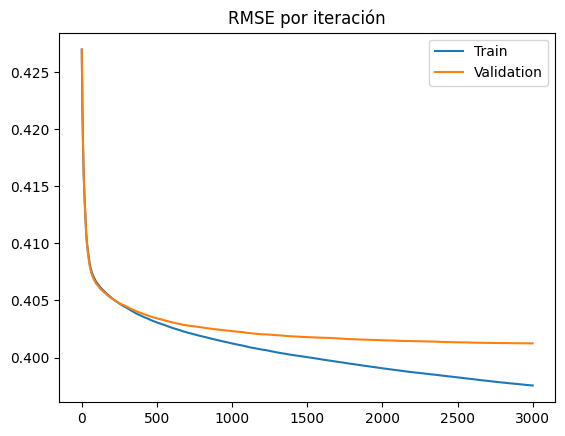

In [18]:
import matplotlib.pyplot as plt

plt.plot(metrics['learn']['RMSE'], label='Train')
plt.plot(metrics['validation']['RMSE'], label='Validation')
plt.legend()
plt.title("RMSE por iteración")
plt.show()


In [ ]:
# Guardar modelo LightGBM entrenado con lgb.train
model.save_model(f'model_{version}.cbm')

# Evaluación del modelo con el entorno de test

In [20]:
y_pred_test = model.predict(x_ctx_test)
y_pred_test_int = np.round(y_pred_test).astype(int)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score

# RMSE y MAE
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Exact match
exact_match_test = accuracy_score(y_test, y_pred_test_int)

print("MAE test:", mae_test)
print("RMSE test:", rmse_test)
print("Exact match test:", exact_match_test)

MAE test: 0.19787058294217552
RMSE test: 0.40063016007581415
Exact match test: 0.8933708797288518


In [36]:
y_test.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [39]:
np.unique(y_pred_test_int)

array([1, 2, 3, 4, 5])

## Puede que aquí tengamos un issue, solo vemos 5 clases

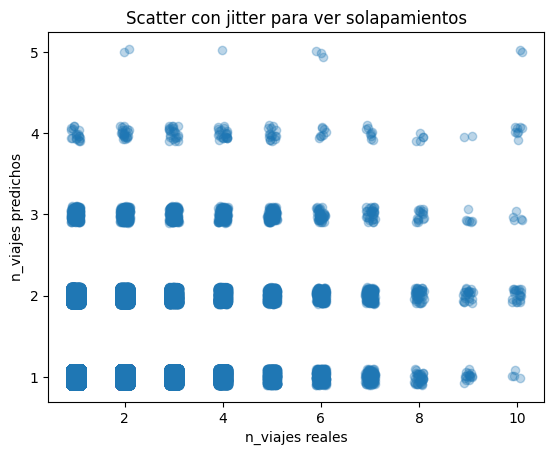

In [35]:
import numpy as np

y_test_j = y_test + np.random.uniform(-0.1, 0.1, size=len(y_test))
y_pred_j = y_pred_test_int + np.random.uniform(-0.1, 0.1, size=len(y_pred_test_int))

plt.scatter(y_test_j, y_pred_j, alpha=0.3)
plt.xlabel("n_viajes reales")
plt.ylabel("n_viajes predichos")
plt.title("Scatter con jitter para ver solapamientos")
plt.show()


## Evaluación del modelo

In [ ]:
y_pred_full = model.predict(x_context)
y_pred_full_int = np.round(y_pred_full).astype(int)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_val, y_pred_full)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_full))
exact_match = (y_pred_full_int == y_val).mean() * 100

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Exact match %: {exact_match:.2f}%")



ValueError: Found input variables with inconsistent numbers of samples: [1351998, 8449988]

In [ ]:
df_eval = df_agg.copy()
df_eval["predicted"] = y_pred_int
df_eval["error"] = df_eval["predicted"] - df_eval["n_viajes"]

# Errores medios por valor real
print(df_eval.groupby("n_viajes")["error"].mean())


n_viajes
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
99    0.0
Name: error, dtype: float64
